# 数据预处理 Pipeline

按照课程要求，依次执行以下5个步骤：
1. 加载原始分钟级数据 + 解析时间 + 插值处理缺失值
2. 计算衍生特征 sub_metering_remainder
3. 按天汇总（部分列求和，部分列求均值）
4. 获取并合并天气数据
5. 划分训练集/测试集并保存

In [1]:
import pandas as pd
import numpy as np
import os

DATA_DIR = r'd:\大学\研究生\Codes\ML\data'
RAW_FILE = os.path.join(DATA_DIR, 'household_power_consumption.txt')
WEATHER_FILE = os.path.join(DATA_DIR, 'MENSQ_92_previous-1950-2024.csv')

## Step 1: 加载原始数据 + 解析时间 + 插值处理缺失值

In [2]:
# 读取数据，将 '?' 视为缺失值
df = pd.read_csv(RAW_FILE, sep=';', na_values='?', low_memory=False)
print(f'原始数据形状: {df.shape}')
print(f'各列缺失值:\n{df.isnull().sum()}')
df.head()

原始数据形状: (2075259, 9)
各列缺失值:
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
# 合并 Date 和 Time 为 datetime，并设为索引
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df = df.drop(columns=['Date', 'Time'])
df = df.set_index('datetime').sort_index()

# 确保所有列为数值类型
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'转换后缺失值:\n{df.isnull().sum()}')

转换后缺失值:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [4]:
# 线性插值填补缺失值
df = df.interpolate(method='linear')

# 如果首尾有缺失（插值无法覆盖），用前向/后向填充
df = df.ffill().bfill()

print(f'插值后缺失值:\n{df.isnull().sum()}')
print(f'数据形状: {df.shape}')
df.head()

插值后缺失值:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64
数据形状: (2075259, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Step 2: 计算衍生特征 sub_metering_remainder

公式：`sub_metering_remainder = (Global_active_power * 1000 / 60) - (Sub_metering_1 + Sub_metering_2 + Sub_metering_3)`

In [5]:
df['sub_metering_remainder'] = (
    (df['Global_active_power'] * 1000 / 60)
    - (df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3'])
)

print('新增列 sub_metering_remainder:')
df[['Global_active_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'sub_metering_remainder']].head()

新增列 sub_metering_remainder:


,Global_active_power,Sub_metering_1,Sub_metering_2,Sub_metering_3,sub_metering_remainder
datetime,,,,,
2006-12-16 17:24:00,4.216,0.0,1.0,17.0,52.266667
2006-12-16 17:25:00,5.360,0.0,1.0,16.0,72.333333
2006-12-16 17:26:00,5.374,0.0,2.0,17.0,70.566667
2006-12-16 17:27:00,5.388,0.0,1.0,17.0,71.800000
2006-12-16 17:28:00,3.666,0.0,1.0,17.0,43.100000


## Step 3: 按天汇总

根据PDF要求：
- **求和**：Global_active_power, Global_reactive_power, Sub_metering_1, Sub_metering_2, Sub_metering_3, sub_metering_remainder
- **求均值**：Voltage, Global_intensity

In [6]:
# 按天汇总
sum_cols = [
    'Global_active_power', 'Global_reactive_power',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
    'sub_metering_remainder'
]
mean_cols = ['Voltage', 'Global_intensity']

daily_sum = df[sum_cols].resample('D').sum()
daily_mean = df[mean_cols].resample('D').mean()

daily_df = pd.concat([daily_sum, daily_mean], axis=1)

print(f'按天汇总后数据形状: {daily_df.shape}')
print(f'缺失值:\n{daily_df.isnull().sum()}')
daily_df.head()

按天汇总后数据形状: (1442, 8)
缺失值:
Global_active_power       0
Global_reactive_power     0
Sub_metering_1            0
Sub_metering_2            0
Sub_metering_3            0
sub_metering_remainder    0
Voltage                   0
Global_intensity          0
dtype: int64


,Global_active_power,Global_reactive_power,Sub_metering_1,Sub_metering_2,Sub_metering_3,sub_metering_remainder,Voltage,Global_intensity
datetime,,,,,,,,
2006-12-16,1209.176,34.922,0.0,546.0,4926.0,14680.933333,236.243763,13.082828
2006-12-17,3390.460,226.006,2033.0,4187.0,13341.0,36946.666667,240.087028,9.999028
2006-12-18,2203.826,161.792,1063.0,2621.0,14018.0,19028.433333,241.231694,6.421667
2006-12-19,1666.194,150.942,839.0,7602.0,6197.0,13131.900000,241.999313,4.926389
2006-12-20,2225.748,160.998,0.0,2648.0,14063.0,20384.800000,242.308063,6.467361


## Step 4: 获取并合并天气数据

天气数据来源：法国气象局月度基础气候数据（MENSQ）
需要的列：RR, NBJRR1, NBJRR5, NBJRR10, NBJBROU
这些是月度数据，需映射到每一天（同月内所有天共享该月的值）

In [7]:
# 读取天气数据
weather = pd.read_csv(WEATHER_FILE, sep=';', low_memory=False)
print(f'天气数据形状: {weather.shape}')
print(f'列名: {list(weather.columns)}')
weather.head()

天气数据形状: (7560, 162)
列名: ['NUM_POSTE', 'NOM_USUEL', 'LAT', 'LON', 'ALTI', 'AAAAMM', 'RR', 'QRR', 'NBRR', 'RR_ME', 'RRAB', 'QRRAB', 'RRABDAT', 'NBJRR1', 'NBJRR5', 'NBJRR10', 'NBJRR30', 'NBJRR50', 'NBJRR100', 'PMERM', 'QPMERM', 'NBPMERM', 'PMERMINAB', 'QPMERMINAB', 'PMERMINABDAT', 'TX', 'QTX', 'NBTX', 'TX_ME', 'TXAB', 'QTXAB', 'TXDAT', 'TXMIN', 'QTXMIN', 'TXMINDAT', 'NBJTX0', 'NBJTX25', 'NBJTX30', 'NBJTX35', 'NBJTXI20', 'NBJTXI27', 'NBJTXS32', 'TN', 'QTN', 'NBTN', 'TN_ME', 'TNAB', 'QTNAB', 'TNDAT', 'TNMAX', 'QTNMAX', 'TNMAXDAT', 'NBJTN5', 'NBJTN10', 'NBJTNI10', 'NBJTNI15', 'NBJTNI20', 'NBJTNS20', 'NBJTNS25', 'NBJGELEE', 'TAMPLIM', 'QTAMPLIM', 'TAMPLIAB', 'QTAMPLIAB', 'TAMPLIABDAT', 'NBTAMPLI', 'TM', 'QTM', 'NBTM', 'TMM', 'QTMM', 'NBTMM', 'NBJTMS24', 'TMMIN', 'QTMMIN', 'TMMINDAT', 'TMMAX', 'QTMMAX', 'TMMAXDAT', 'UNAB', 'QUNAB', 'UNABDAT', 'NBUN', 'UXAB', 'QUXAB', 'UXABDAT', 'NBUX', 'UMM', 'QUMM', 'NBUM', 'TSVM', 'QTSVM', 'NBTSVM', 'ETP', 'QETP', 'FXIAB', 'QFXIAB', 'DXIAB', 'QDXIAB', 'FXIDA

,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,AAAAMM,RR,QRR,NBRR,RR_ME,...,QNEIGETOTM,NEIGETOTAB,QNEIGETOTAB,NEIGETOTABDAT,NBJNEIGETOT1,NBJNEIGETOT10,NBJNEIGETOT30,NBJGREL,NBJORAG,NBJBROU
0,92002001,ANTONY-TOURVOIE,48.753333,2.298333,55,195801,83.5,1.0,31.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,92002001,ANTONY-TOURVOIE,48.753333,2.298333,55,195802,87.8,1.0,28.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,92002001,ANTONY-TOURVOIE,48.753333,2.298333,55,195803,25.0,1.0,31.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,92002001,ANTONY-TOURVOIE,48.753333,2.298333,55,195804,45.3,1.0,30.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,92002001,ANTONY-TOURVOIE,48.753333,2.298333,55,195805,59.9,1.0,31.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# 筛选巴黎附近的气象站（电力数据采集自法国 Sceaux，靠近巴黎）
# 常用站点：Paris-Montsouris (7156) 或 Orly (7149)
# 先查看有哪些巴黎区域站点
paris_stations = weather[
    weather['NOM_USUEL'].str.contains('PARIS|ORLY|MONTSOURIS|SCEAUX|CLAMART', case=False, na=False)
]
print('巴黎区域气象站:')
paris_stations[['NUM_POSTE', 'NOM_USUEL', 'LAT', 'LON']].drop_duplicates()

巴黎区域气象站:


,NUM_POSTE,NOM_USUEL,LAT,LON
1359,92023001,CLAMART,48.778333,2.231667
1921,92023003,CLAMART-BECLERE,48.786667,2.256667
6133,92071001,SCEAUX,48.768333,2.291667
6511,92071002,SCEAUX,48.780000,2.290000


In [9]:
# SCEAUX站数据只到2004年，改用SURESNES站（距Sceaux约6km，数据覆盖2006-2010）
weather_station = weather[weather['NOM_USUEL'] == 'SURESNES']

if len(weather_station) == 0:
    weather_station = weather
    print('未找到 SURESNES 站，使用全部数据')
else:
    print(f'使用气象站: SURESNES')
print(f'数据条数: {len(weather_station)}')

使用气象站: SURESNES
数据条数: 899


In [10]:
# 提取需要的天气列，并筛选 2006-2010 年的数据
weather_cols = ['AAAAMM', 'RR', 'NBJRR1', 'NBJRR5', 'NBJRR10', 'NBJBROU']
weather_sel = weather_station[weather_cols].copy()

# 筛选时间范围：200612 到 201011
weather_sel['AAAAMM'] = weather_sel['AAAAMM'].astype(int)
weather_sel = weather_sel[(weather_sel['AAAAMM'] >= 200612) & (weather_sel['AAAAMM'] <= 201011)]
weather_sel = weather_sel.sort_values('AAAAMM').reset_index(drop=True)

# 将 AAAAMM 转为日期格式（每月1号）
weather_sel['date'] = pd.to_datetime(weather_sel['AAAAMM'].astype(str) + '01', format='%Y%m%d')

print(f'筛选后天气数据: {weather_sel.shape}')
weather_sel.head()

筛选后天气数据: (48, 7)


,AAAAMM,RR,NBJRR1,NBJRR5,NBJRR10,NBJBROU,date
0,200612,67.8,9.0,5.0,3.0,NaN,2006-12-01
1,200701,23.4,10.0,0.0,0.0,NaN,2007-01-01
2,200702,78.0,13.0,6.0,2.0,NaN,2007-02-01
3,200703,39.0,12.0,3.0,0.0,NaN,2007-03-01
4,200704,11.5,1.0,1.0,1.0,NaN,2007-04-01


In [11]:
# 将月度天气数据映射到每一天
# 同一个月内所有天共享该月的天气值
weather_sel['year'] = weather_sel['date'].dt.year
weather_sel['month'] = weather_sel['date'].dt.month

daily_df_reset = daily_df.reset_index()
daily_df_reset['year'] = daily_df_reset['datetime'].dt.year
daily_df_reset['month'] = daily_df_reset['datetime'].dt.month

# 合并：按年月匹配
weather_merge_cols = ['year', 'month', 'RR', 'NBJRR1', 'NBJRR5', 'NBJRR10', 'NBJBROU']
daily_merged = daily_df_reset.merge(
    weather_sel[weather_merge_cols],
    on=['year', 'month'],
    how='left'
)

# 整理：去掉辅助列，设回 datetime 索引
daily_merged = daily_merged.drop(columns=['year', 'month']).set_index('datetime')

# 对天气缺失值做前向填充（同一月内后续天共享）
daily_merged[['RR', 'NBJRR1', 'NBJRR5', 'NBJRR10', 'NBJBROU']] = (
    daily_merged[['RR', 'NBJRR1', 'NBJRR5', 'NBJRR10', 'NBJBROU']].ffill().bfill()
)

print(f'合并后数据形状: {daily_merged.shape}')
print(f'缺失值:\n{daily_merged.isnull().sum()}')
daily_merged.head()

合并后数据形状: (1442, 13)
缺失值:
Global_active_power       0
Global_reactive_power     0
Sub_metering_1            0
Sub_metering_2            0
Sub_metering_3            0
sub_metering_remainder    0
Voltage                   0
Global_intensity          0
RR                        0
NBJRR1                    0
NBJRR5                    0
NBJRR10                   0
NBJBROU                   0
dtype: int64


,Global_active_power,Global_reactive_power,Sub_metering_1,Sub_metering_2,Sub_metering_3,sub_metering_remainder,Voltage,Global_intensity,RR,NBJRR1,NBJRR5,NBJRR10,NBJBROU
datetime,,,,,,,,,,,,,
2006-12-16,1209.176,34.922,0.0,546.0,4926.0,14680.933333,236.243763,13.082828,67.8,9.0,5.0,3.0,2.0
2006-12-17,3390.460,226.006,2033.0,4187.0,13341.0,36946.666667,240.087028,9.999028,67.8,9.0,5.0,3.0,2.0
2006-12-18,2203.826,161.792,1063.0,2621.0,14018.0,19028.433333,241.231694,6.421667,67.8,9.0,5.0,3.0,2.0
2006-12-19,1666.194,150.942,839.0,7602.0,6197.0,13131.900000,241.999313,4.926389,67.8,9.0,5.0,3.0,2.0
2006-12-20,2225.748,160.998,0.0,2648.0,14063.0,20384.800000,242.308063,6.467361,67.8,9.0,5.0,3.0,2.0


划分结果应该是：
数据集	天数	占比
训练集	~987	68%
测试集	~455	32%

In [12]:
# 后 455 天作为测试集（90天输入 + 365天输出 = 455）
test_df = daily_merged.iloc[-455:]
train_df = daily_merged.iloc[:-455]
train_df.to_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df.to_csv(os.path.join(DATA_DIR, 'test.csv'))

## 数据概览

In [14]:
# 查看最终数据统计信息
daily_merged.describe()

,Global_active_power,Global_reactive_power,Sub_metering_1,Sub_metering_2,Sub_metering_3,sub_metering_remainder,Voltage,Global_intensity,RR,NBJRR1,NBJRR5,NBJRR10,NBJBROU
count,1442.000000,1442.000000,1442.000000,1442.000000,1442.000000,1442.000000,1442.000000,1442.000000,1442.000000,1442.000000,1442.000000,1442.000000,1442.0
mean,1569.079348,177.950196,1596.718793,1855.398405,9271.580097,13427.625173,240.830431,4.625764,49.892718,9.300971,3.459778,1.099861,2.0
std,601.879575,50.224652,1587.452018,2086.646144,3774.422948,6128.403571,2.050027,1.743678,23.285244,3.616350,1.841794,1.019457,0.0
min,250.298000,24.722474,0.000000,0.000000,0.000000,2313.633333,231.088229,0.808333,7.500000,1.000000,0.000000,0.000000,2.0
25%,1168.101000,142.516000,579.750000,430.250000,6658.750000,9375.983333,240.068363,3.500799,32.900000,7.000000,2.000000,0.000000,2.0
50%,1549.344000,171.304000,1110.500000,687.000000,9287.500000,12644.533333,240.962701,4.549375,50.100000,9.000000,3.000000,1.000000,2.0
75%,1900.137000,203.823000,2200.000000,2727.250000,11771.750000,16531.850000,241.869840,5.539236,65.100000,12.000000,4.000000,2.000000,2.0
max,4773.386000,417.834000,11224.000000,12109.000000,23743.000000,61736.433333,247.435007,14.028056,133.300000,19.000000,8.000000,4.000000,2.0


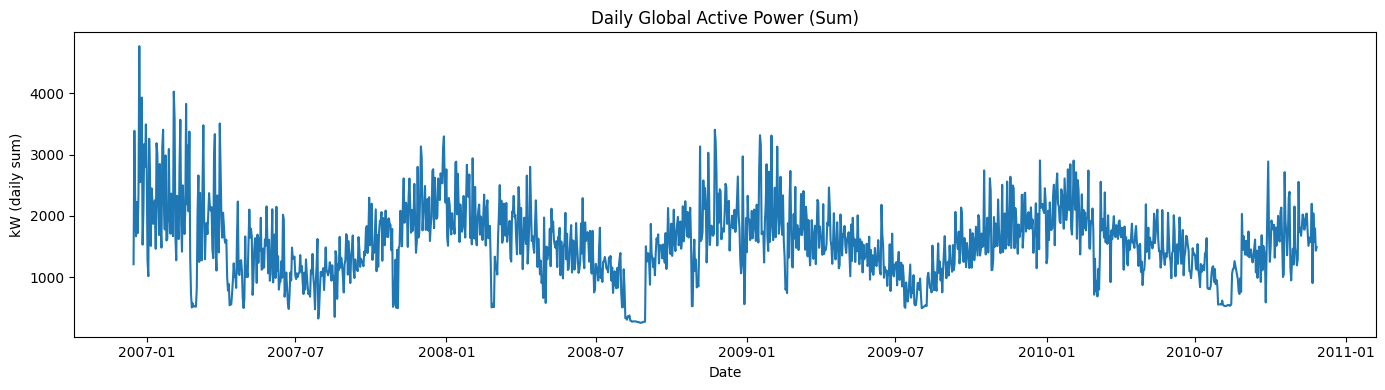

In [15]:
# 绘制 Global_active_power 的日汇总曲线
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(daily_merged.index, daily_merged['Global_active_power'])
plt.title('Daily Global Active Power (Sum)')
plt.xlabel('Date')
plt.ylabel('kW (daily sum)')
plt.tight_layout()
plt.show()